In [3]:
# ============================================
# SIMPLE & CLEAN ANOMALY DETECTION NOTEBOOK
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import f1_score
import time

In [4]:
# ============================================
# 1. DATASET
# ============================================

np.random.seed(42)

# Synthetic dataset
X, _ = make_blobs(n_samples=300, centers=2, cluster_std=0.8)
outliers = np.random.uniform(low=-8, high=8, size=(30, 2))
X = np.vstack([X, outliers])
y = np.array([0]*300 + [1]*30)

X = StandardScaler().fit_transform(X)

In [5]:
# ============================================
# 2. MODELS
# ============================================

models = {
    "Isolation Forest": IsolationForest(contamination=0.1),
    "One-Class SVM": OneClassSVM(nu=0.1),
    "LOF": LocalOutlierFactor(contamination=0.1)
}

results = {}

In [6]:
# ============================================
# 3. TRAIN + EVALUATE
# ============================================

for name, model in models.items():
    
    start = time.time()
    
    if name == "LOF":
        pred = model.fit_predict(X)
    else:
        model.fit(X)
        pred = model.predict(X)
    
    pred = (pred == -1).astype(int)
    
    f1 = f1_score(y, pred)
    elapsed = time.time() - start
    
    results[name] = {
        "pred": pred,
        "f1": f1,
        "time": elapsed
    }

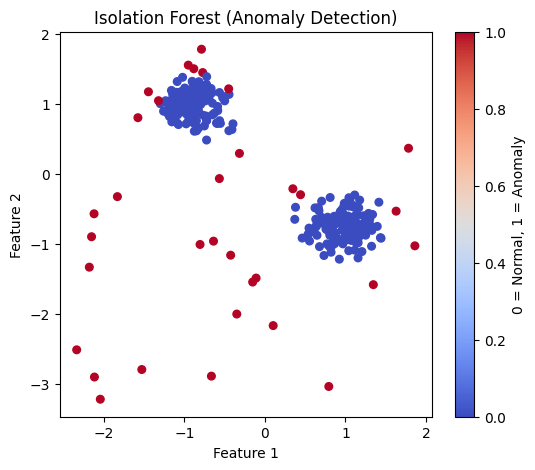

In [7]:
# ============================================
# 4. SIMPLE SCATTER PLOT
# ============================================

plt.figure(figsize=(6,5))

pred = results["Isolation Forest"]["pred"]

plt.scatter(X[:,0], X[:,1],
            c=pred,
            cmap="coolwarm",
            s=30)

plt.title("Isolation Forest (Anomaly Detection)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="0 = Normal, 1 = Anomaly")

plt.show()

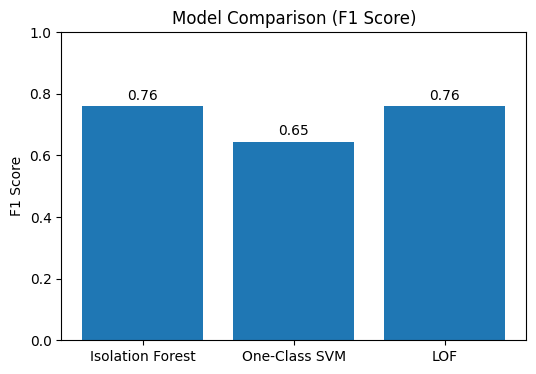

In [8]:
# ============================================
# 5. F1 SCORE COMPARISON
# ============================================

names = list(results.keys())
f1_scores = [results[n]["f1"] for n in names]

plt.figure(figsize=(6,4))

plt.bar(names, f1_scores)

plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")

for i, v in enumerate(f1_scores):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center')

plt.ylim(0,1)

plt.show()

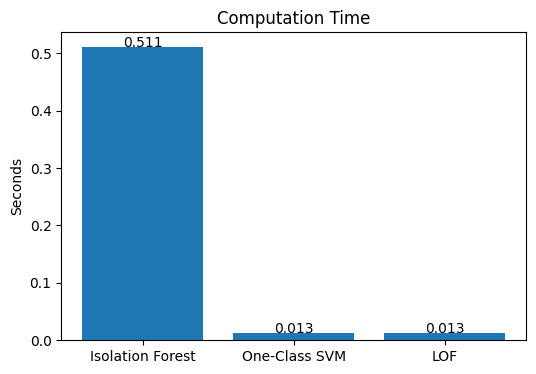

In [9]:
# ============================================
# 6. TIME COMPARISON
# ============================================

times = [results[n]["time"] for n in names]

plt.figure(figsize=(6,4))

plt.bar(names, times)

plt.title("Computation Time")
plt.ylabel("Seconds")

for i, v in enumerate(times):
    plt.text(i, v, f"{v:.3f}", ha='center')

plt.show()

In [10]:

# 7. PRINT RESULTS
  

print("\nModel Performance:\n")

for name in results:
    print(f"{name}: F1 = {results[name]['f1']:.3f}, Time = {results[name]['time']:.4f}s")


Model Performance:

Isolation Forest: F1 = 0.762, Time = 0.5108s
One-Class SVM: F1 = 0.645, Time = 0.0132s
LOF: F1 = 0.762, Time = 0.0133s


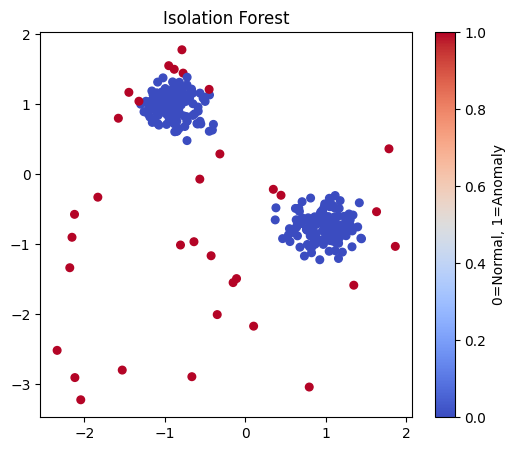

In [11]:
plt.figure(figsize=(6,5))
pred = results["Isolation Forest"]["pred"]
plt.scatter(X[:,0], X[:,1], c=pred, cmap="coolwarm", s=30)
plt.title("Isolation Forest")
plt.colorbar(label="0=Normal, 1=Anomaly")

plt.savefig("scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

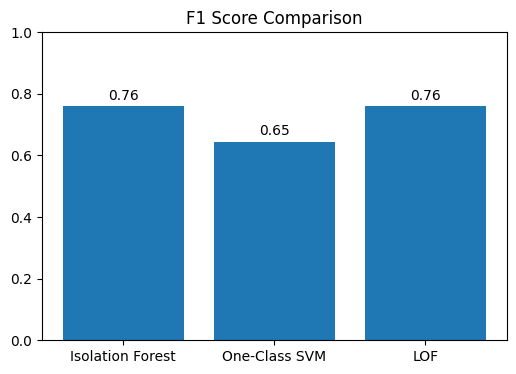

In [12]:
plt.figure(figsize=(6,4))
plt.bar(names, f1_scores)
plt.title("F1 Score Comparison")

for i, v in enumerate(f1_scores):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center')

plt.ylim(0,1)

plt.savefig("f1_score.png", dpi=300, bbox_inches="tight")
plt.show()

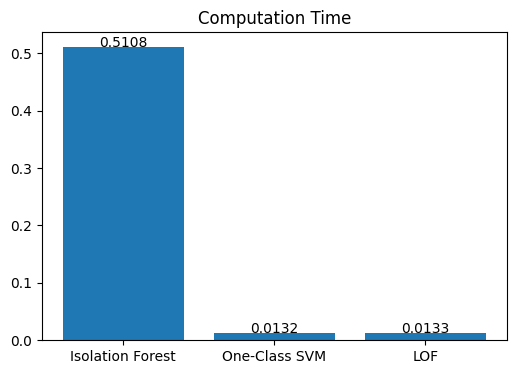

In [13]:
plt.figure(figsize=(6,4))
plt.bar(names, times)
plt.title("Computation Time")

for i, v in enumerate(times):
    plt.text(i, v, f"{v:.4f}", ha='center')

plt.savefig("time_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
